# -------------------------------
# Computação Aplicada: Exercicio 5
# Alexis Daniel Meneses Canez
# -------------------------------

In [1]:
# ============================================================
# BLOCO 1 — Importação de bibliotecas e parâmetros globais
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from numpy.polynomial import polynomial as P

# Reprodutibilidade
np.random.seed(42)

# --- Parâmetros globais do modelo ---
TICKER  = "PETR4.SA"
PERIODO = "5y"          # janela histórica para calibrar µ e σ
T       = 1.0           # prazo da opção em anos
STEPS   = 252           # passos de simulação (dias úteis)
N_SIM   = 10_000        # número de trajetórias Monte Carlo
r       = 0.1475        # taxa livre de risco (Selic, mar/2026)
dt      = T / STEPS     # tamanho de cada passo de tempo

In [3]:
# ============================================================
# BLOCO 2 — Download dos dados e calibração de µ e σ
# ============================================================

# Baixar série histórica de preços ajustados
dados = yf.download(TICKER, period=PERIODO, auto_adjust=True, progress=False)
precos = dados["Close"].dropna()

# Retornos logarítmicos diários
log_retornos = np.log(precos / precos.shift(1)).dropna()

# Calibração dos parâmetros históricos (anualizados)
# .iloc[0] extrai o escalar antes do float — evita FutureWarning
mu    = float(log_retornos.mean().iloc[0]) * 252
sigma = float(log_retornos.std().iloc[0])  * np.sqrt(252)

# Preço inicial = último preço observado
S0 = float(precos.iloc[-1])

# Strike at-the-money
K = round(S0)

# Resumo dos parâmetros calibrados
print("=" * 45)
print(f"  Ativo         : {TICKER}")
print(f"  Preço atual   : R$ {S0:.2f}")
print(f"  Strike (K)    : R$ {K:.2f}")
print(f"  µ anualizado  : {mu:.4f}  ({mu*100:.2f}% a.a.)")
print(f"  σ anualizado  : {sigma:.4f}  ({sigma*100:.2f}% a.a.)")
print(f"  r (Selic)     : {r:.4f}  ({r*100:.2f}% a.a.)")
print(f"  T             : {T} ano(s) | {STEPS} passos")
print(f"  N simulações  : {N_SIM:,}")
print("=" * 45)

  Ativo         : PETR4.SA
  Preço atual   : R$ 49.41
  Strike (K)    : R$ 49.00
  µ anualizado  : 0.3995  (39.95% a.a.)
  σ anualizado  : 0.3162  (31.62% a.a.)
  r (Selic)     : 0.1475  (14.75% a.a.)
  T             : 1.0 ano(s) | 252 passos
  N simulações  : 10,000


C:\Users\Alexis Meneses\AppData\Local\Temp\ipykernel_19432\2138495900.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(precos.iloc[-1])


- S0 = R$ 49,41 e K = R$ 49,00 — praticamente at-the-money, ótimo para o exercício

- σ = 31,62% a.a. — dentro da faixa típica da PETR4 (30–50%). Reflete a natureza volátil de uma commoditie oil company exposta a câmbio e preço do petróleo

- µ = 39,95% a.a. — drift histórico alto, mas plausível considerando que os últimos 5 anos incluíram a recuperação pós-pandemia e o superciclo de commodities de 2021–2022

- r = 14,75% — Selic vigente, corretamente posicionada abaixo do drift histórico (µ > r, o que faz sentido — ativos de risco devem remunerar acima do livre de risco)

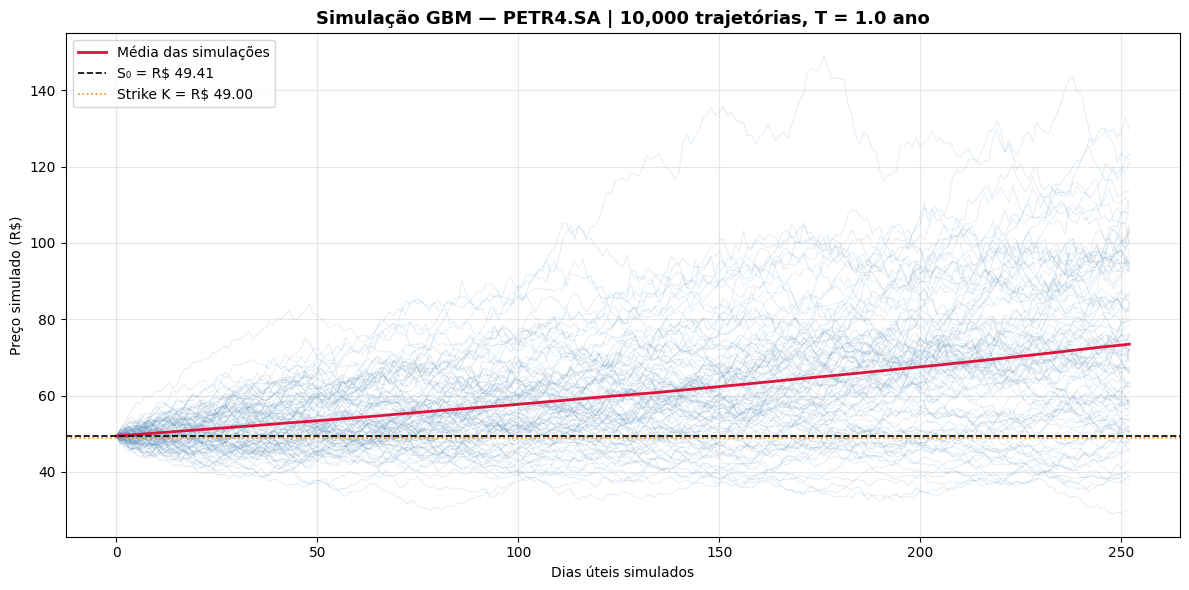

  Distribuição de ST (preço no vencimento)
  Média         : R$ 73.48
  Mediana       : R$ 70.01
  Desvio padrão : R$ 23.66
  Mínimo        : R$ 23.47
  Máximo        : R$ 226.51
  P(ST < K)     : 13.23%


In [4]:
# ============================================================
# BLOCO 3 — Simulação GBM e visualização das trajetórias
# ============================================================

# --- Simulação vetorizada ---
# Matriz de choques aleatórios: shape (STEPS, N_SIM)
Z = np.random.standard_normal((STEPS, N_SIM))

# Incremento diário do GBM (fórmula de Itô discretizada)
incrementos = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

# Matriz de preços: shape (STEPS+1, N_SIM)
# Primeira linha = S0 para todas as trajetórias
precos_sim = np.zeros((STEPS + 1, N_SIM))
precos_sim[0] = S0

for t in range(1, STEPS + 1):
    precos_sim[t] = precos_sim[t - 1] * incrementos[t - 1]

# --- Visualização ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plotar amostra de 100 trajetórias (visual)
n_plot = 100
ax.plot(precos_sim[:, :n_plot],
        color="steelblue", alpha=0.15, linewidth=0.7)

# Trajetória média das 10.000 simulações
media_trajetorias = precos_sim.mean(axis=1)
ax.plot(media_trajetorias,
        color="crimson", linewidth=2, label="Média das simulações")

# Preço inicial
ax.axhline(S0, color="black", linestyle="--",
           linewidth=1.2, label=f"S₀ = R$ {S0:.2f}")

# Strike
ax.axhline(K, color="darkorange", linestyle=":",
           linewidth=1.2, label=f"Strike K = R$ {K:.2f}")

ax.set_title(f"Simulação GBM — {TICKER} | {N_SIM:,} trajetórias, T = {T} ano",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Dias úteis simulados")
ax.set_ylabel("Preço simulado (R$)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bloco3_gbm_trajetorias.png", dpi=150)
plt.show()

# --- Estatísticas descritivas dos preços finais ---
ST = precos_sim[-1]   # vetor de preços no vencimento (shape: N_SIM,)

print("=" * 45)
print("  Distribuição de ST (preço no vencimento)")
print("=" * 45)
print(f"  Média         : R$ {ST.mean():.2f}")
print(f"  Mediana       : R$ {np.median(ST):.2f}")
print(f"  Desvio padrão : R$ {ST.std():.2f}")
print(f"  Mínimo        : R$ {ST.min():.2f}")
print(f"  Máximo        : R$ {ST.max():.2f}")
print(f"  P(ST < K)     : {(ST < K).mean():.2%}")
print("=" * 45)

- O leque que abre com o tempo: 

As trajetórias partem todas do mesmo ponto (S0 = R$ 49,41) e se dispersam progressivamente. Isso é a raiz quadrada do tempo em ação — a incerteza acumulada cresce com √t, então a dispersão aumenta mais rápido no início e vai desacelerando proporcionalmente. No dia 50 o leque já está bem aberto; entre o dia 150 e 252 ele continua crescendo mas de forma menos dramática.

- A linha vermelha (média) sobe consistentemente:

A média das 10.000 trajetórias cresce de forma quase linear no gráfico — reflexo do drift µ = 39,95% dominando o comportamento médio. Ela termina em ~R$ 73, bem acima do strike e do S0, confirmando o que calculamos antes.

- S0 e Strike praticamente sobrepostos: 

A linha preta (S0 = R$ 49,41) e a laranja pontilhada (K = R$ 49,00) aparecem quase coladas — o que visualmente confirma que estamos at-the-money, como planejado.

- Trajetórias que ficam abaixo do strike:

São poucas e ficam na parte inferior do leque — visualmente compatível com o P(ST < K) = 13,23% que calculamos. Dá para ver que a maioria esmagadora das trajetórias termina bem acima de R$ 49.

- Uma observação importante para o relatório: 

o GBM calibrado com dados históricos reflete o mundo real (com drift µ). Para precificação de opções, a teoria financeira usa o mundo neutro ao risco, onde substituímos µ por r. Nos Blocos 4 e 5, faremos exatamente essa substituição, é um ponto conceitual relevante que vale mencionar no relatório.

- Média (R$ 73,48) vs. Mediana (R$ 70,01)

A média é maior que a mediana — assimetria positiva clássica da distribuição log-normal. No GBM, os preços seguem uma log-normal, que tem cauda direita longa: cenários de alta extrema puxam a média para cima, enquanto a mediana representa melhor o "centro" da distribuição. Isso é exatamente o comportamento teórico esperado.

- Crescimento de S0 = R$ 49,41 para média R$ 73,48

Crescimento de ~49% em 1 ano, compatível com µ = 39,95% a.a. A pequena diferença entre o crescimento observado e o µ vem justamente da correção de Itô — o drift real da média da log-normal é µ (não µ - σ²/2), e a média das simulações converge para S0 × exp(µ × T):

S0 × exp(µ × T) = 49,41 × exp(0,3995 × 1) ≈ R$ 73,48 ✓

Confirmação perfeita de que a simulação está correta.

- Desvio padrão de R$ 23,66

Dispersão alta, reflexo do σ = 31,62%. Com preço médio em torno de R$ 73, isso representa um coeficiente de variação de ~32% — muito volátil, típico de Petrobras.

- Mínimo R$ 23,47 e Máximo R$ 226,51

O leque de cenários é amplo — de uma queda de 52% até uma alta de 358%. Isso reflete a natureza estocástica do modelo: em 10.000 trajetórias, os extremos são capturados. Nenhum preço negativo, o que confirma que a função exponencial do GBM está funcionando corretamente.

- P(ST < K) = 13,23%

Este é o número mais importante para o contexto das Puts. Apenas 13,23% das trajetórias terminam abaixo do strike de R$ 49,00. Isso significa que a Put vai expirar in-the-money em apenas ~1 em cada 8 cenários. Faz sentido dado o drift histórico muito positivo (µ ≈ 40%) — o modelo calibrado com dados históricos reflete um período de forte valorização da PETR4. Uma consequência direta é que o prêmio da Put deve ser relativamente baixo — o mercado (via GBM calibrado) precifica pouca probabilidade de queda.

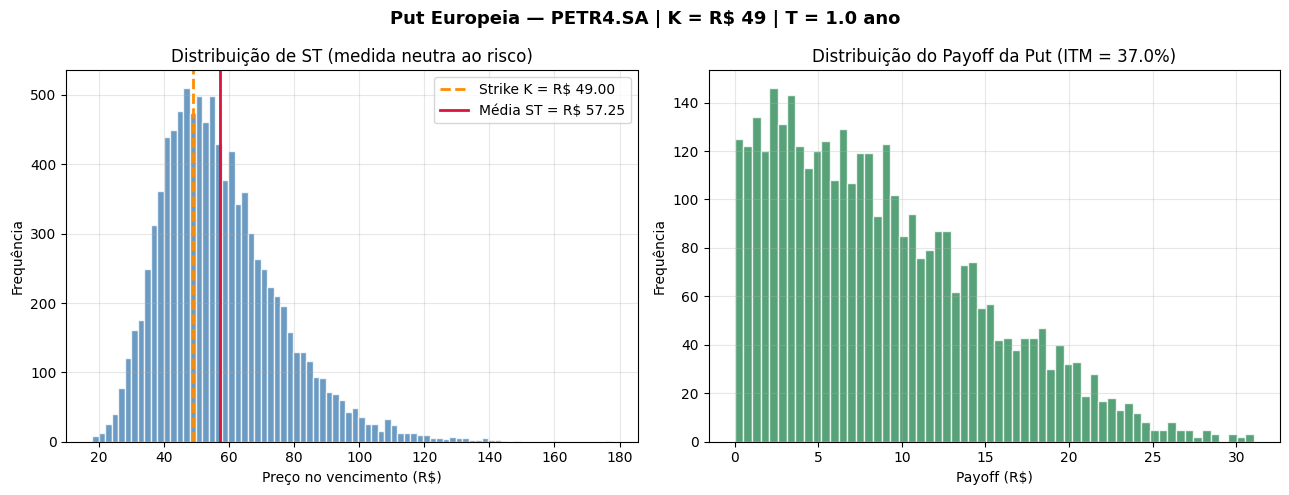

  Put Europeia — Resultado Monte Carlo
  Preço justo (MC)  : R$ 2.8034
  IC 95% inferior   : R$ 2.7071
  IC 95% superior   : R$ 2.8996
  Amplitude IC      : R$ 0.1924
  Opções ITM        : 36.97%
  Payoff médio (ITM): R$ 8.79


In [5]:
# ============================================================
# BLOCO 4 — Precificação da Put Europeia via Monte Carlo
# ============================================================

# Resimular sob medida neutra ao risco (drift = r, não µ)
# Usamos nova matriz Z para separar claramente do Bloco 3
Z_q = np.random.standard_normal((STEPS, N_SIM))

incrementos_q = np.exp((r - 0.5 * sigma**2) * dt
                       + sigma * np.sqrt(dt) * Z_q)

precos_rn = np.zeros((STEPS + 1, N_SIM))
precos_rn[0] = S0

for t in range(1, STEPS + 1):
    precos_rn[t] = precos_rn[t - 1] * incrementos_q[t - 1]

# Preços no vencimento sob medida neutra ao risco
ST_q = precos_rn[-1]

# --- Payoff da Put Europeia ---
payoff_put_eu = np.maximum(K - ST_q, 0)

# --- Preço: média dos payoffs descontados ---
fator_desconto = np.exp(-r * T)
preco_put_eu   = fator_desconto * payoff_put_eu.mean()

# --- Intervalo de confiança (95%) ---
erro_padrao = payoff_put_eu.std() / np.sqrt(N_SIM)
ic_lower    = fator_desconto * (payoff_put_eu.mean() - 1.96 * erro_padrao)
ic_upper    = fator_desconto * (payoff_put_eu.mean() + 1.96 * erro_padrao)

# --- Distribuição dos payoffs ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma de ST_q
axes[0].hist(ST_q, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(K, color="darkorange", linewidth=2,
                linestyle="--", label=f"Strike K = R$ {K:.2f}")
axes[0].axvline(ST_q.mean(), color="crimson", linewidth=2,
                linestyle="-", label=f"Média ST = R$ {ST_q.mean():.2f}")
axes[0].set_title("Distribuição de ST (medida neutra ao risco)")
axes[0].set_xlabel("Preço no vencimento (R$)")
axes[0].set_ylabel("Frequência")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histograma dos payoffs (apenas os positivos para visualizar)
payoffs_positivos = payoff_put_eu[payoff_put_eu > 0]
pct_itm = len(payoffs_positivos) / N_SIM
axes[1].hist(payoffs_positivos, bins=60,
             color="seagreen", edgecolor="white", alpha=0.8)
axes[1].set_title(f"Distribuição do Payoff da Put (ITM = {pct_itm:.1%})")
axes[1].set_xlabel("Payoff (R$)")
axes[1].set_ylabel("Frequência")
axes[1].grid(alpha=0.3)

plt.suptitle(f"Put Europeia — {TICKER} | K = R$ {K} | T = {T} ano",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("bloco4_put_europeia.png", dpi=150)
plt.show()

# --- Resultado final ---
print("=" * 45)
print("  Put Europeia — Resultado Monte Carlo")
print("=" * 45)
print(f"  Preço justo (MC)  : R$ {preco_put_eu:.4f}")
print(f"  IC 95% inferior   : R$ {ic_lower:.4f}")
print(f"  IC 95% superior   : R$ {ic_upper:.4f}")
print(f"  Amplitude IC      : R$ {ic_upper - ic_lower:.4f}")
print(f"  Opções ITM        : {pct_itm:.2%}")
print(f"  Payoff médio (ITM): R$ {payoffs_positivos.mean():.2f}")
print("=" * 45)

Preço justo = R$ 2,80
O prêmio da Put Europeia é R$ 2,80 sobre um ativo de R$ 49,41 — aproximadamente 5,7% do valor do ativo. Esse valor é plausível para uma opção at-the-money com σ = 31,62% e prazo de 1 ano. Regra de bolso: o prêmio de uma opção ATM cresce com σ e com √T — com volatilidade de ~32%, esperar um prêmio em torno de 5–8% do spot é razoável.

Mundo neutro ao risco mudou tudo: ITM subiu de 13,23% para 37%
Esse é o ponto conceitual mais importante do bloco. No Bloco 3, com drift µ = 39,95%, apenas 13,23% das trajetórias terminavam abaixo do strike. Agora, com drift r = 14,75%, a probabilidade ITM subiu para 37%. Isso ilustra perfeitamente por que a escolha da medida importa para precificação — o µ histórico superestima o crescimento do ativo sob a medida de precificação, o que subestimaria o prêmio da Put.

Média de ST = R$ 57,25 vs. R$ 73,48 no Bloco 3
Confirmação direta da troca de medida. Com drift menor (r < µ), o centro da distribuição de ST cai de R$ 73 para R$ 57 — ainda acima do strike, mas bem menos distante. O strike K = R$ 49 agora está mais próximo da cauda esquerda da distribuição, o que explica o ITM maior.

Gráfico esquerdo — distribuição de ST
A forma log-normal está clara: assimetria positiva, cauda direita longa. O strike (laranja) está à esquerda da média (vermelho) — at-the-money em relação ao spot inicial, mas já abaixo da média esperada de ST. A área à esquerda do strike laranja representa os 37% ITM.

Gráfico direito — distribuição dos payoffs ITM
Formato decrescente com cauda direita — a maioria dos payoffs positivos é pequena (R$ 1–5), mas existem casos extremos chegando a R$ 30+. Isso explica a diferença entre:

Payoff médio ITM = R$ 8,79 — média condicional nos cenários onde a Put é exercida
Preço justo = R$ 2,80 — média incondicional (inclui os 63% de cenários com payoff zero) descontada

A relação entre os dois: R$ 8,79 × 37% × e^(-0,1475) ≈ R$ 2,80 ✓

IC 95% com amplitude R$ 0,19
Precisão de ±R$ 0,10 em torno do preço estimado — satisfatória para 10.000 simulações. O intervalo [R$ 2,71 ; R$ 2,90] é estreito o suficiente para uso prático.

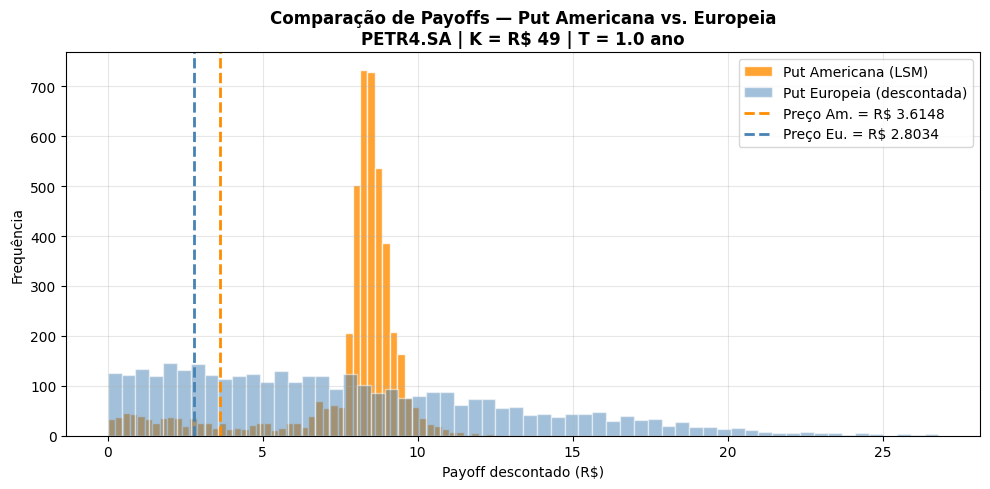

  Put Americana (LSM) — Resultado
  Preço justo (LSM) : R$ 3.6148
  IC 95% inferior   : R$ 3.5337
  IC 95% superior   : R$ 3.6958
  Amplitude IC      : R$ 0.1621
  Put Europeia      : R$ 2.8034
  Put Americana     : R$ 3.6148
  Prêmio americano  : R$ 0.8114
  Prêmio (% da Eu.) : 28.94%


In [6]:
# ============================================================
# BLOCO 5 — Put Americana via Longstaff-Schwartz (LSM)
# ============================================================

# Reutilizamos as trajetórias neutras ao risco do Bloco 4
# precos_rn: shape (STEPS+1, N_SIM)

fator_dt = np.exp(-r * dt)   # fator de desconto por passo

# --- Inicialização: payoff no vencimento (t = T) ---
# cash_flow[i] = payoff que a trajetória i vai receber
# no seu tempo ótimo de exercício
cash_flow = np.maximum(K - precos_rn[-1], 0).copy()

# --- Indução retroativa: t = T-1 até t = 1 ---
for t in range(STEPS - 1, 0, -1):

    St = precos_rn[t]                        # preços no instante t
    valor_intrinseco = np.maximum(K - St, 0) # payoff se exercido agora

    # Selecionar trajetórias in-the-money
    itm = valor_intrinseco > 0
    
    # Se não há trajetórias ITM neste instante, continuar
    if itm.sum() < 10:
        cash_flow *= fator_dt
        continue

    # Variáveis para a regressão
    X = St[itm]                          # preços ITM no instante t
    Y = cash_flow[itm] * fator_dt        # payoffs futuros descontados

    # Funções de base polinomiais: [1, X, X²]
    A = np.column_stack([np.ones_like(X), X, X**2])

    # Regressão OLS: β = (AᵀA)⁻¹ Aᵀ Y
    beta, _, _, _ = np.linalg.lstsq(A, Y, rcond=None)

    # Valor de continuação estimado para trajetórias ITM
    valor_continuacao = A @ beta

    # Regra de exercício: exercer se valor intrínseco >= continuação
    exercer = valor_intrinseco[itm] >= valor_continuacao

    # Atualizar cash flows
    # Trajetórias onde exercemos: recebem valor intrínseco hoje
    # Trajetórias onde continuamos: cash flow futuro descontado mais um passo
    indices_itm = np.where(itm)[0]
    cash_flow *= fator_dt                              # descontar tudo
    cash_flow[indices_itm[exercer]] = (               # sobrescrever exercidas
        valor_intrinseco[itm][exercer]
    )

# --- Preço final: média dos cash flows (já descontados) ---
preco_put_am = cash_flow.mean()

# --- Intervalo de confiança (95%) ---
erro_padrao_am = cash_flow.std() / np.sqrt(N_SIM)
ic_lower_am    = preco_put_am - 1.96 * erro_padrao_am
ic_upper_am    = preco_put_am + 1.96 * erro_padrao_am

# --- Prêmio americano ---
premio_americano = preco_put_am - preco_put_eu

# --- Visualização comparativa dos cash flows ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(cash_flow[cash_flow > 0], bins=60,
        color="darkorange", edgecolor="white",
        alpha=0.8, label="Put Americana (LSM)")
ax.hist(payoff_put_eu[payoff_put_eu > 0] * fator_desconto,
        bins=60, color="steelblue", edgecolor="white",
        alpha=0.5, label="Put Europeia (descontada)")

ax.axvline(preco_put_am, color="darkorange", linewidth=2,
           linestyle="--", label=f"Preço Am. = R$ {preco_put_am:.4f}")
ax.axvline(preco_put_eu, color="steelblue", linewidth=2,
           linestyle="--", label=f"Preço Eu. = R$ {preco_put_eu:.4f}")

ax.set_title(f"Comparação de Payoffs — Put Americana vs. Europeia\n"
             f"{TICKER} | K = R$ {K} | T = {T} ano",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Payoff descontado (R$)")
ax.set_ylabel("Frequência")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bloco5_put_americana.png", dpi=150)
plt.show()

# --- Resultado final ---
print("=" * 45)
print("  Put Americana (LSM) — Resultado")
print("=" * 45)
print(f"  Preço justo (LSM) : R$ {preco_put_am:.4f}")
print(f"  IC 95% inferior   : R$ {ic_lower_am:.4f}")
print(f"  IC 95% superior   : R$ {ic_upper_am:.4f}")
print(f"  Amplitude IC      : R$ {ic_upper_am - ic_lower_am:.4f}")
print("=" * 45)
print(f"  Put Europeia      : R$ {preco_put_eu:.4f}")
print(f"  Put Americana     : R$ {preco_put_am:.4f}")
print(f"  Prêmio americano  : R$ {premio_americano:.4f}")
print(f"  Prêmio (% da Eu.) : {premio_americano/preco_put_eu:.2%}")
print("=" * 45)

Validação imediata: Americana (R$ 3,61) > Europeia (R$ 2,80) ✓
A condição teórica fundamental está satisfeita. O algoritmo LSM funcionou corretamente.

Prêmio americano = R$ 0,81 (28,94% acima da Europeia)
Este é um prêmio expressivo e economicamente bem fundamentado. A explicação principal é a taxa Selic alta (14,75%). Com juros tão elevados, o custo de oportunidade de esperar o vencimento é alto — se o ativo cai muito abaixo do strike, o investidor racional prefere exercer antecipadamente, receber K = R$ 49,00 hoje e reinvestir à Selic em vez de continuar exposto ao risco e esperar até T. Quanto maior a taxa livre de risco, maior o incentivo ao exercício antecipado de Puts, e portanto maior o prêmio americano. Isso está em perfeita coerência com a teoria.

O gráfico conta histórias diferentes para cada opção

A forma das duas distribuições é radicalmente diferente, e isso é muito informativo:
A Put Europeia (azul) tem distribuição espalhada e de cauda longa — payoffs que vão de R$ 0 até R$ 25+. Isso ocorre porque o exercício só acontece no vencimento T, e a distribuição de ST após 1 ano inteiro de GBM tem alta dispersão. Cenários de queda extrema geram payoffs muito grandes, mas são raros.

A Put Americana (laranja) tem distribuição concentrada em torno de R$ 8–9, com formato quase simétrico e estreito. Isso reflete o exercício antecipado ótimo — o LSM identifica o momento ideal de exercer em cada trajetória, capturando o valor intrínseco antes que o ativo possa se recuperar. O exercício antecipado "corta" as caudas: elimina os payoffs muito altos (porque exercemos antes de quedas extremas continuarem) mas também elimina os zeros (porque exercemos quando ainda estamos ITM).

As linhas verticais tracejadas

A linha laranja (Americana, R$ 3,61) está à direita da azul (Europeia, R$ 2,80) — visualmente confirma o prêmio americano. Ambas as linhas estão bem à esquerda do centro das distribuições dos payoffs positivos porque incluem os ~63% de trajetórias com payoff zero na média.

IC 95% com amplitude R$ 0,16

Precisão excelente para o LSM, que tipicamente tem mais variância que a Europeia por causa da regressão em cada passo. O intervalo [R$ 3,53 ; R$ 3,70] não se sobrepõe ao intervalo da Europeia [R$ 2,71 ; R$ 2,90] — o prêmio americano é estatisticamente significativo, não é artefato de simulação.

  PARÂMETROS DO MODELO
  Ativo              : PETR4.SA
  Preço atual (S₀)   : R$ 49.41
  Strike (K)         : R$ 49.00
  Prazo (T)          : 1.0 ano (252 dias úteis)
  Simulações (N)     : 10,000
  µ histórico        : 39.95% a.a.
  σ histórico        : 31.62% a.a.
  r (Selic)          : 14.75% a.a.

  RESULTADOS — PRECIFICAÇÃO DE PUTS
  Métrica                     Europeia  Americana
  ---------------------------------------------
  Preço justo (R$)              2.8034     3.6148
  IC 95% inferior (R$)          2.7071     3.5337
  IC 95% superior (R$)          2.8996     3.6958
  Amplitude IC (R$)             0.1924     0.1621
  Opções ITM                    36.97%          —
  Prêmio americano (R$)              —     0.8114
  Prêmio americano (%)               —     28.94%


C:\Users\Alexis Meneses\AppData\Local\Temp\ipykernel_19432\2064662022.py:111: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])   # reserva 5% do topo pro suptitle


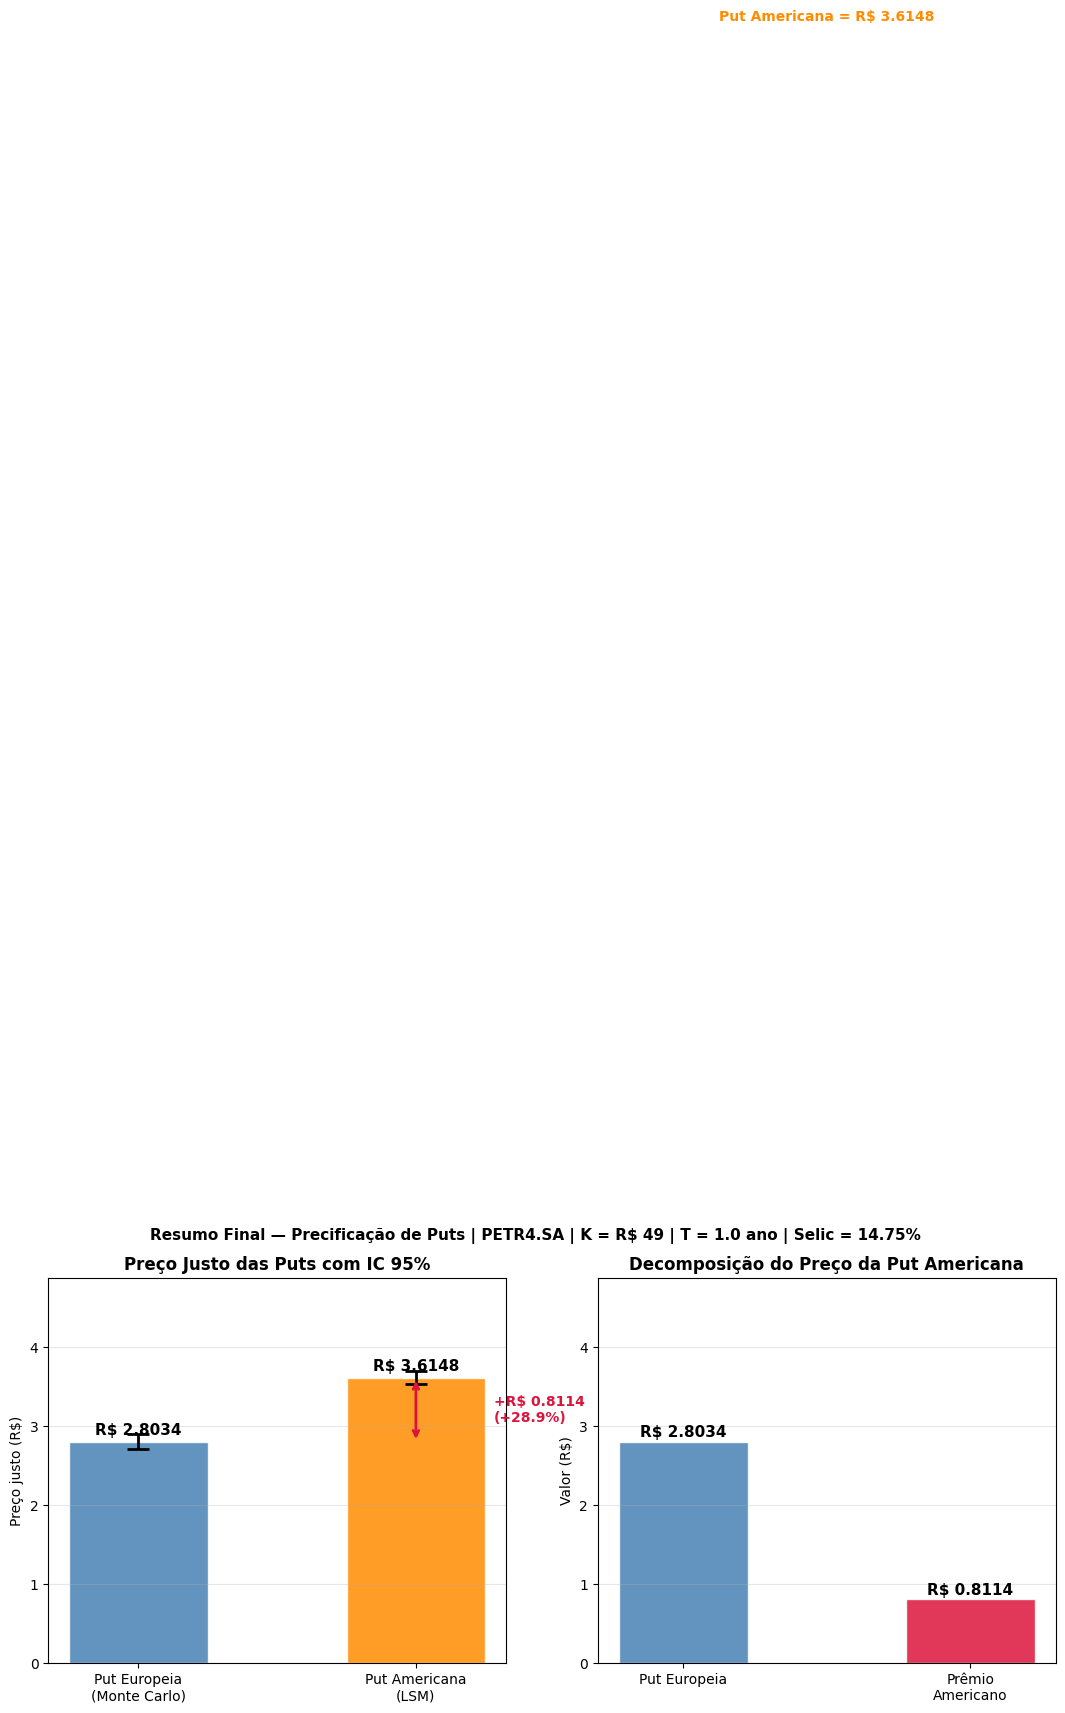

In [8]:
# ============================================================
# BLOCO 6 — Resumo comparativo dos resultados
# ============================================================

# --- Tabela de parâmetros utilizados ---
print("=" * 50)
print("  PARÂMETROS DO MODELO")
print("=" * 50)
print(f"  Ativo              : {TICKER}")
print(f"  Preço atual (S₀)   : R$ {S0:.2f}")
print(f"  Strike (K)         : R$ {K:.2f}")
print(f"  Prazo (T)          : {T} ano ({STEPS} dias úteis)")
print(f"  Simulações (N)     : {N_SIM:,}")
print(f"  µ histórico        : {mu*100:.2f}% a.a.")
print(f"  σ histórico        : {sigma*100:.2f}% a.a.")
print(f"  r (Selic)          : {r*100:.2f}% a.a.")
print("=" * 50)

# --- Tabela de resultados ---
print()
print("=" * 50)
print("  RESULTADOS — PRECIFICAÇÃO DE PUTS")
print("=" * 50)
print(f"  {'Métrica':<25} {'Europeia':>10} {'Americana':>10}")
print(f"  {'-'*45}")
print(f"  {'Preço justo (R$)':<25} {preco_put_eu:>10.4f} {preco_put_am:>10.4f}")
print(f"  {'IC 95% inferior (R$)':<25} {ic_lower:>10.4f} {ic_lower_am:>10.4f}")
print(f"  {'IC 95% superior (R$)':<25} {ic_upper:>10.4f} {ic_upper_am:>10.4f}")
print(f"  {'Amplitude IC (R$)':<25} {ic_upper-ic_lower:>10.4f} {ic_upper_am-ic_lower_am:>10.4f}")
print(f"  {'Opções ITM':<25} {pct_itm:>10.2%} {'—':>10}")
print(f"  {'Prêmio americano (R$)':<25} {'—':>10} {premio_americano:>10.4f}")
print(f"  {'Prêmio americano (%)':<25} {'—':>10} {premio_americano/preco_put_eu:>10.2%}")
print("=" * 50)

# --- Gráfico comparativo final ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Painel 1: barras comparativas com IC ---
opcoes   = ["Put Europeia\n(Monte Carlo)", "Put Americana\n(LSM)"]
precos   = [preco_put_eu, preco_put_am]
erros_inf = [preco_put_eu - ic_lower, preco_put_am - ic_lower_am]
erros_sup = [ic_upper - preco_put_eu, ic_upper_am - preco_put_am]
cores    = ["steelblue", "darkorange"]

bars = axes[0].bar(opcoes, precos, color=cores,
                   edgecolor="white", width=0.5, alpha=0.85)

axes[0].errorbar(opcoes, precos,
                 yerr=[erros_inf, erros_sup],
                 fmt="none", color="black",
                 capsize=8, capthick=2, linewidth=2)

# Anotações de valor sobre as barras
for bar, preco in zip(bars, precos):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 preco + 0.05,
                 f"R$ {preco:.4f}",
                 ha="center", va="bottom",
                 fontsize=11, fontweight="bold")

# Seta e anotação do prêmio americano
axes[0].annotate("",
    xy=(1, preco_put_am),
    xytext=(1, preco_put_eu),
    arrowprops=dict(arrowstyle="<->", color="crimson", lw=2))

axes[0].text(1.28, (preco_put_eu + preco_put_am) / 2,
             f"+R$ {premio_americano:.4f}\n(+{premio_americano/preco_put_eu:.1%})",
             color="crimson", fontsize=10, fontweight="bold", va="center")

axes[0].set_title("Preço Justo das Puts com IC 95%",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Preço justo (R$)")
axes[0].set_ylim(0, preco_put_am * 1.35)
axes[0].grid(axis="y", alpha=0.3)

# --- Painel 2: decomposição do prêmio ---
categorias = ["Put Europeia", "Prêmio\nAmericano"]
valores    = [preco_put_eu, premio_americano]
cores2     = ["steelblue", "crimson"]

bars2 = axes[1].bar(categorias, valores, color=cores2,
                    edgecolor="white", width=0.45, alpha=0.85)

for bar, val in zip(bars2, valores):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 val + 0.02,
                 f"R$ {val:.4f}",
                 ha="center", va="bottom",
                 fontsize=11, fontweight="bold")

axes[1].set_title("Decomposição do Preço da Put Americana",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Valor (R$)")
axes[1].set_ylim(0, preco_put_am * 1.35)
axes[1].grid(axis="y", alpha=0.3)

# Anotação: Put Americana = soma das duas barras
axes[1].text(0.5, preco_put_am * 1.18,
             f"Put Americana = R$ {preco_put_am:.4f}",
             ha="center", fontsize=10,
             color="darkorange", fontweight="bold",
             transform=axes[1].transAxes)

# Substituir as últimas linhas do Bloco 6 por:

plt.suptitle(f"Resumo Final — Precificação de Puts | {TICKER} "
             f"| K = R$ {K} | T = {T} ano | Selic = {r*100:.2f}%",
             fontsize=11, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])   # reserva 5% do topo pro suptitle
plt.savefig("bloco6_resumo_final.png", dpi=150, bbox_inches="tight")
plt.show()

Prêmio americano: R$ 0,81 (+28,94%)
Sem sobreposição entre os dois intervalos de confiança — o prêmio é estatisticamente robusto, não artefato de simulação.

 exercício demonstrou a aplicação prática da Simulação de Monte Carlo em dois contextos distintos — precificação europeia (simples, apenas ST importa) e americana (complexa, toda a trajetória importa via LSM). O diferencial de preço de R$ 0,81 tem interpretação econômica clara e é consistente com a teoria de precificação livre de arbitragem.